In [6]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("nih-chest-xrays/data")

# print("Path to dataset files:", path)

# Imports

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

print("TensorFlow Version:", tf.__version__)
print("Dependencies loaded successfully!")

TensorFlow Version: 2.19.0
Dependencies loaded successfully!


# Load metadata and connect images

In [ ]:
BASE_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
CSV_PATH = os.path.join(BASE_PATH, "Data_Entry_2017.csv")

image_paths = {}
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.lower().endswith(".png"):
            image_paths[file] = os.path.join(root, file)

df = pd.read_csv(CSV_PATH)
print("Metadata shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Total images found: 112120
Metadata shape: (112120, 12)

First few rows:
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x 

In [ ]:
df = df.copy()

if "View Position" in df.columns:
    df = df[df["View Position"].isin(["PA", "AP"])].copy()

df = df[
    (df["Finding Labels"] == "No Finding") |
    (df["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

df["label"] = df["Finding Labels"].apply(lambda x: 1 if "Pneumonia" in x else 0)

df["path"] = df["Image Index"].map(image_paths)

keep_cols = ["Image Index", "Finding Labels", "label", "path"]
if "Patient ID" in df.columns:
    keep_cols.append("Patient ID")
if "View Position" in df.columns:
    keep_cols.append("View Position")

df = df[keep_cols].dropna(subset=["path"]).drop_duplicates().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nFinding Labels distribution:")
print(df['Finding Labels'].value_counts())

Filtered dataset shape: (61792, 6)

Label distribution:
label
0    60361
1     1431
Name: count, dtype: int64

Finding Labels distribution:
Finding Labels
No Finding                                                  60361
Pneumonia                                                     322
Infiltration|Pneumonia                                        199
Edema|Infiltration|Pneumonia                                  137
Atelectasis|Pneumonia                                         108
                                                            ...  
Mass|Nodule|Pneumonia|Pneumothorax                              1
Atelectasis|Effusion|Infiltration|Pneumonia|Pneumothorax        1
Cardiomegaly|Consolidation|Effusion|Pneumonia                   1
Consolidation|Nodule|Pneumonia                                  1
Consolidation|Pneumonia|Mass                                    1
Name: count, Length: 143, dtype: int64


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after:", df.duplicated().sum())

print("\nUnique patients:", df["Patient ID"].nunique() if "Patient ID" in df.columns else "Patient ID not found")
print("Unique images:", df["Image Index"].nunique())

print("\nCLASS DISTRIBUTION (Image-Level)")
print(df["label"].value_counts())
print("\nClass ratio:")
print(df["label"].value_counts(normalize=True))

if "Patient ID" in df.columns:
    print("\nCLASS DISTRIBUTION (Patient-Level)")
    patient_level = df.groupby("Patient ID")["label"].max().value_counts()
    print(patient_level)

Missing values per column:
Image Index       0
Finding Labels    0
label             0
path              0
Patient ID        0
View Position     0
dtype: int64

DUPLICATES ANALYSIS
Duplicates before: 0
Duplicates after: 0

DATASET OVERVIEW
Unique patients: 25052
Unique images: 61792

CLASS DISTRIBUTION (Image-Level)
label
0    60361
1     1431
Name: count, dtype: int64

Class ratio:
label
0    0.976842
1    0.023158
Name: proportion, dtype: float64

CLASS DISTRIBUTION (Patient-Level)
label
0    24044
1     1008
Name: count, dtype: int64


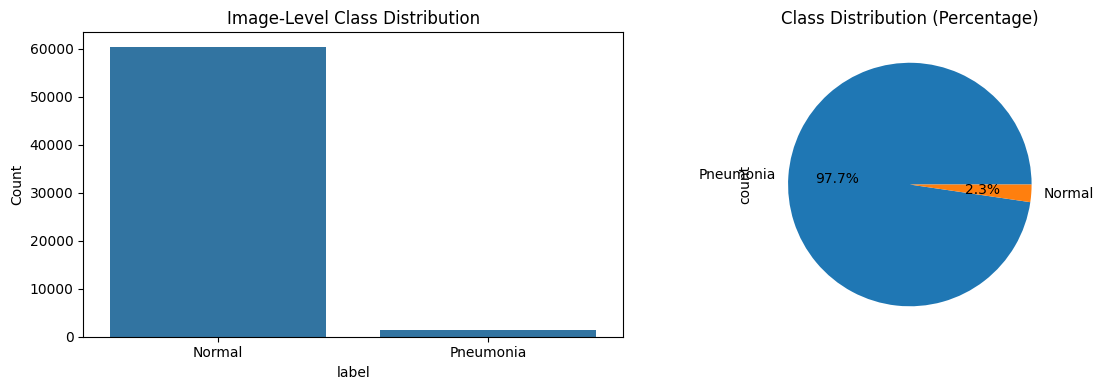

Visualization complete!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=df["label"], ax=axes[0])
axes[0].set_xticklabels(["Normal", "Pneumonia"])
axes[0].set_title("Image-Level Class Distribution")
axes[0].set_ylabel("Count")

df["label"].value_counts().plot(kind="pie", ax=axes[1], labels=["Pneumonia", "Normal"], autopct="%1.1f%%")
axes[1].set_title("Class Distribution (Percentage)")
plt.tight_layout()
plt.show()

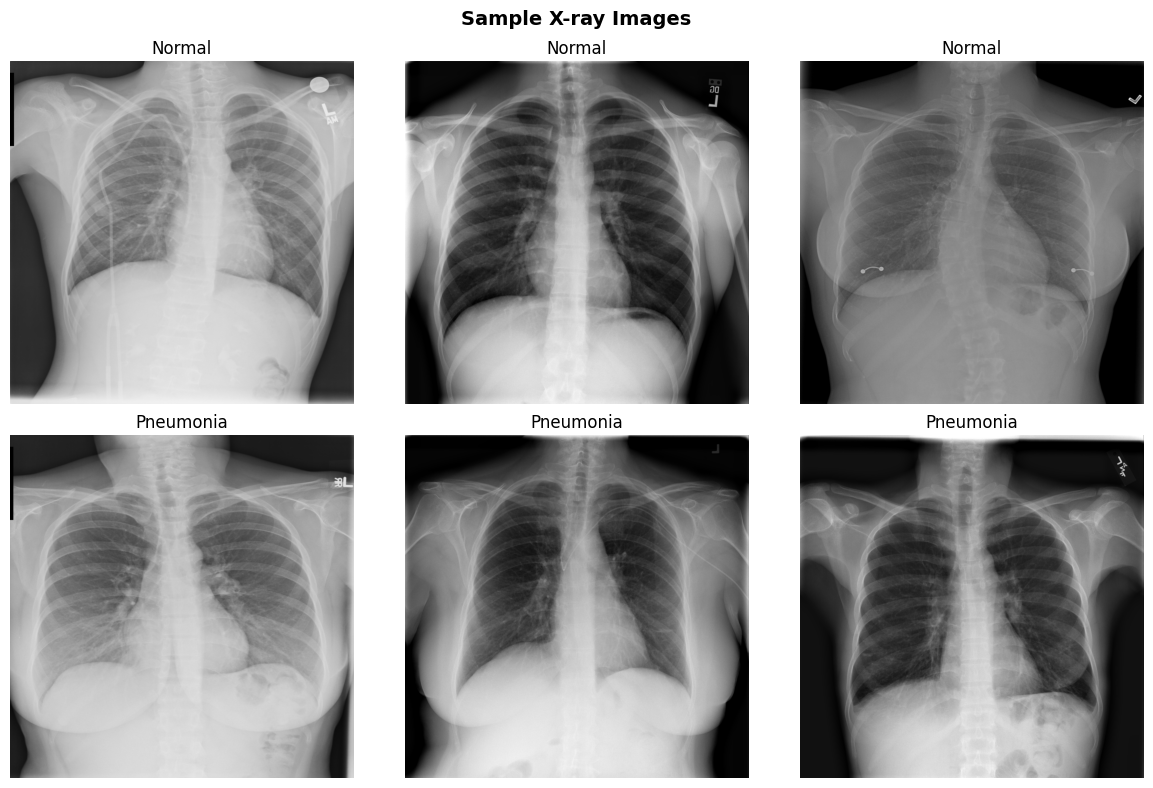

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Sample X-ray Images", fontsize=14, fontweight="bold")

normal_samples = df[df["label"] == 0].sample(3, random_state=42)
pneumonia_samples = df[df["label"] == 1].sample(3, random_state=42)

all_samples = pd.concat([normal_samples, pneumonia_samples]).reset_index(drop=True)

for i, (_, row) in enumerate(all_samples.iterrows()):
    ax = axes[i // 3, i % 3]
    img = cv2.imread(row["path"])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img, cmap='gray')
    label_text = "Pneumonia" if row["label"] == 1 else "Normal"
    ax.set_title(f"{label_text}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Data preprocessing

IMAGE DIMENSION ANALYSIS
       Height   Width
count   200.0   200.0
mean   1024.0  1024.0
std       0.0     0.0
min    1024.0  1024.0
25%    1024.0  1024.0
50%    1024.0  1024.0
75%    1024.0  1024.0
max    1024.0  1024.0


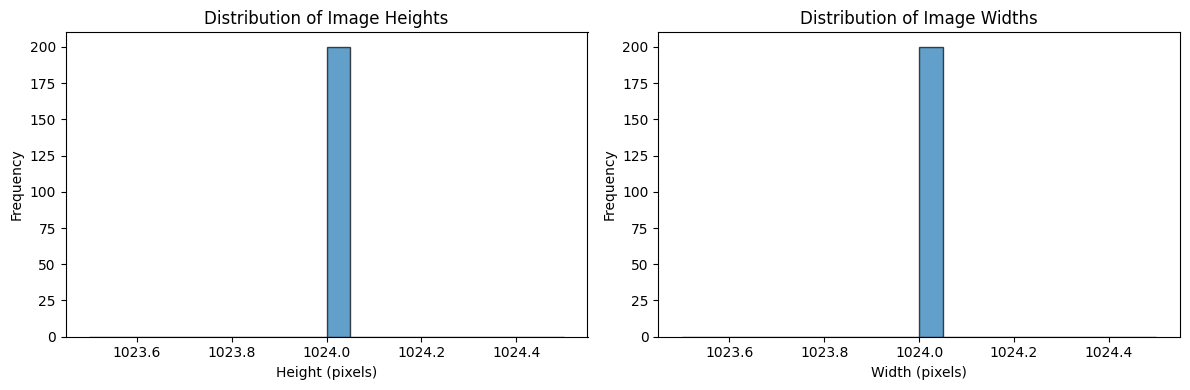

In [ ]:
sizes = []

for p in df["path"].sample(min(200, len(df)), random_state=42):
    try:
        img = cv2.imread(p)
        if img is not None:
            sizes.append(img.shape[:2])
    except Exception as e:
        continue

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])

print("IMAGE DIMENSION ANALYSIS")
print(sizes_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sizes_df["Height"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Height (pixels)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Image Heights")

axes[1].hist(sizes_df["Width"], bins=20, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Image Widths")

plt.tight_layout()
plt.show()

# Class imbalance strategy

In [ ]:
df_model = df.copy().reset_index(drop=True)

print(df_model["label"].value_counts())
print(df_model.shape)

label
0    60361
1     1431
Name: count, dtype: int64
(61792, 6)


IMAGE DIMENSION ANALYSIS
       Height   Width
count   200.0   200.0
mean   1024.0  1024.0
std       0.0     0.0
min    1024.0  1024.0
25%    1024.0  1024.0
50%    1024.0  1024.0
75%    1024.0  1024.0
max    1024.0  1024.0


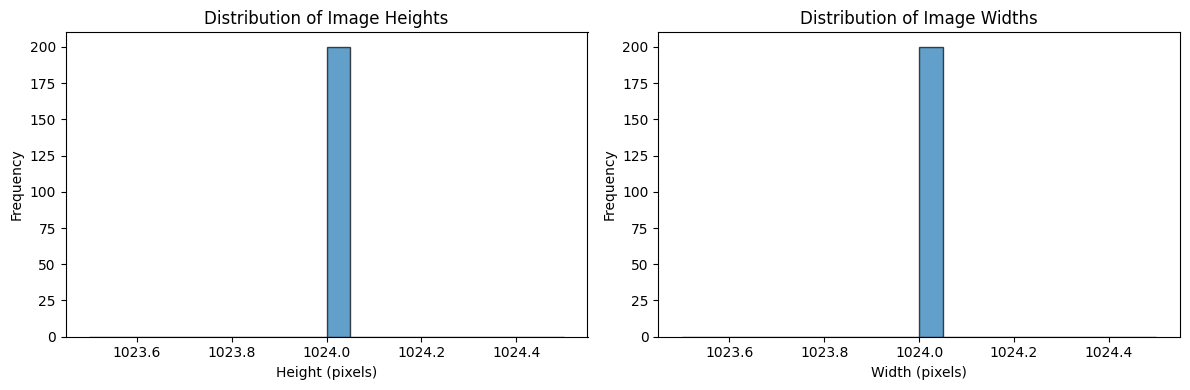

In [ ]:
sizes = []

for p in df["path"].sample(min(200, len(df)), random_state=42):
    try:
        img = cv2.imread(p)
        if img is not None:
            sizes.append(img.shape[:2])
    except Exception as e:
        continue

sizes_df = pd.DataFrame(sizes, columns=["Height", "Width"])

print("IMAGE DIMENSION ANALYSIS")
print(sizes_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sizes_df["Height"], bins=20, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Height (pixels)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Image Heights")

axes[1].hist(sizes_df["Width"], bins=20, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Image Widths")

plt.tight_layout()
plt.show()

In [ ]:
df_model = df.copy().reset_index(drop=True)

assert "Patient ID" in df_model.columns, "Patient ID column is required for patient-level split."

patient_labels = df_model.groupby("Patient ID")["label"].max().reset_index()

train_pat, temp_pat = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["label"],
    random_state=SEED
)

val_pat, test_pat = train_test_split(
    temp_pat,
    test_size=0.50,
    stratify=temp_pat["label"],
    random_state=SEED
)

train_df = df_model[df_model["Patient ID"].isin(train_pat["Patient ID"])].copy()
val_df   = df_model[df_model["Patient ID"].isin(val_pat["Patient ID"])].copy()
test_df  = df_model[df_model["Patient ID"].isin(test_pat["Patient ID"])].copy()

print("TRAIN/VAL/TEST SPLIT")
print(f"Train set: {train_df.shape[0]} images from {train_df['Patient ID'].nunique()} patients")
print(f"Validation set: {val_df.shape[0]} images from {val_df['Patient ID'].nunique()} patients")
print(f"Test set: {test_df.shape[0]} images from {test_df['Patient ID'].nunique()} patients")

print("\nTrain label counts:")
print(train_df["label"].value_counts())
print("\nValidation label counts:")
print(val_df["label"].value_counts())
print("\nTest label counts:")
print(test_df["label"].value_counts())

assert set(train_df["Patient ID"]).isdisjoint(set(val_df["Patient ID"]))
assert set(train_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
assert set(val_df["Patient ID"]).isdisjoint(set(test_df["Patient ID"]))
print("\n✓ No patient leakage detected.")

TRAIN/VAL/TEST SPLIT
Train set: 43018 images from 17536 patients
Validation set: 9271 images from 3758 patients
Test set: 9503 images from 3758 patients

Train label counts:
label
0    42043
1      975
Name: count, dtype: int64

Validation label counts:
label
0    9070
1     201
Name: count, dtype: int64

Test label counts:
label
0    9248
1     255
Name: count, dtype: int64

✓ No patient leakage detected.


In [ ]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1])
}

print("Class Weights (for handling imbalance):")
print(class_weights)

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.03, 0.03),
    tf.keras.layers.RandomZoom(0.05, 0.05),
], name="train_augmentation")

print(f"\nImage size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")


Class Weights (for handling imbalance):
{0: 0.5115952715077421, 1: 22.06051282051282}

Image size: 224x224
Batch size: 32


I0000 00:00:1776518246.482867    4397 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776518246.488963    4397 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.grayscale_to_rgb(image)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

def prepare_train(path, label):
    image, label = decode_image(path, label)
    image = train_augmentation(image, training=True)
    image = preprocess_input(image)
    return image, label

def prepare_eval(path, label):
    image, label = decode_image(path, label)
    image = preprocess_input(image)
    return image, label

def make_dataset(dataframe, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["path"].values,
        dataframe["label"].values.astype("float32")
    ))
    if training:
        ds = ds.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(prepare_train, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(prepare_eval, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Data pipeline functions defined.")

Data pipeline functions defined.


In [ ]:
train_gen = make_dataset(train_df, training=True)
val_gen = make_dataset(val_df, training=False)
test_gen = make_dataset(test_df, training=False)

print("DATASET PIPELINE VERIFICATION")

for images, labels in train_gen.take(1):
    print(f"Batch image shape: {images.shape}")
    print(f"Batch label shape: {labels.shape}")
    print(f"Unique labels in batch: {np.unique(labels.numpy())}")
    print(f"Label counts in batch: {np.unique(labels.numpy(), return_counts=True)}")
    
print("\n✓ Dataset pipeline ready for model training.")

DATASET PIPELINE VERIFICATION
Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Unique labels in batch: [0. 1.]
Label counts in batch: (array([0., 1.], dtype=float32), array([30,  2]))

✓ Dataset pipeline ready for model training.


In [ ]:
def build_densenet_model_v1(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = DenseNet121(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = False
    
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs, name="DenseNet121_v1")
    
    return model, base_model

model_v1, base_model_v1 = build_densenet_model_v1()

print("DENSENET-121 MODEL (INITIAL TRAINING)")
print(model_v1.summary())

DENSENET-121 MODEL (INITIAL TRAINING)


Model: "DenseNet121_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

None


In [ ]:
loss_fn = tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0)

model_v1.compile(
    loss=loss_fn,
    optimizer=Adam(learning_rate=0.001),
    metrics=['AUC', 'Precision', 'Recall']
)

print("Model compiled with:")
print("- Loss: Binary Focal Crossentropy (gamma=2.0)")
print("- Optimizer: Adam (lr=0.001)")
print("- Metrics: AUC, Precision, Recall")


Model compiled with:
- Loss: Binary Focal Crossentropy (gamma=2.0)
- Optimizer: Adam (lr=0.001)
- Metrics: AUC, Precision, Recall


In [ ]:
callbacks_v1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_v1.h5',
        monitor='val_auc',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")

Callbacks configured:
- EarlyStopping (patience=5)
- ReduceLROnPlateau (factor=0.5, patience=3)
- ModelCheckpoint (monitoring val_auc)


In [ ]:
print("TRAINING DENSENET-121 MODEL (v1)")

EPOCHS_V1 = 5

history_v1 = model_v1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_V1,
    class_weight=class_weights,
    callbacks=callbacks_v1,
    verbose=1
)

print("\n Model v1 training completed.")

model_v1.save('densenet121_v1_trained.h5')
print(" Model v1 saved as 'densenet121_v1_trained.h5'")

TRAINING DENSENET-121 MODEL (v1)
Epoch 1/5


I0000 00:00:1776518266.283380    4447 service.cc:152] XLA service 0x7abc50004010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776518266.283430    4447 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776518266.283434    4447 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776518271.014121    4447 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1345 ━━━━━━━━━━━━━━━━━━━━ 11:35:52 31s/step - AUC: 0.0000e+00 - Precision: 0.0000e+00 - Recall: 0.0000e+00 - loss: 0.3012

I0000 00:00:1776518283.754870    4447 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - AUC: 0.5743 - Precision: 0.0285 - Recall: 0.5591 - loss: 0.3481

...

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 598s 444ms/step - AUC: 0.6794 - Precision: 0.0393 - Recall: 0.6530 - loss: 0.1651 - val_AUC: 0.7429 - val_Precision: 0.0524 - val_Recall: 0.6468 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 3/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - AUC: 0.7094 - Precision: 0.0480 - Recall: 0.6415 - loss: 0.1609

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 596s 443ms/step - AUC: 0.7094 - Precision: 0.0480 - Recall: 0.6414 - loss: 0.1609 - val_AUC: 0.7477 - val_Precision: 0.0533 - val_Recall: 0.6070 - val_loss: 0.1483 - learning_rate: 0.0010
Epoch 4/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - AUC: 0.7243 - Precision: 0.0505 - Recall: 0.5975 - loss: 0.1563
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


1345/1345 ━━━━━━━━━━━━━━━━━━━━ 598s 444ms/step - AUC: 0.7243 - Precision: 0.0505 - Recall: 0.5975 - loss: 0.1563 - val_AUC: 0.7615 - val_Precision: 0.0530 - val_Recall: 0.6716 - val_loss: 0.1497 - learning_rate: 0.0010
Epoch 5/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - AUC: 0.7325 - Precision: 0.0517 - Recall: 0.6016 - loss: 0.1560

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 599s 445ms/step - AUC: 0.7325 - Precision: 0.0517 - Recall: 0.6016 - loss: 0.1560 - val_AUC: 0.7568 - val_Precision: 0.0496 - val_Recall: 0.6915 - val_loss: 0.1651 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 1.



✓ Model v1 training completed.
✓ Model v1 saved a s 'densenet121_v1_trained.h5'


Available metrics in history:
dict_keys(['AUC', 'Precision', 'Recall', 'loss', 'val_AUC', 'val_Precision', 'val_Recall', 'val_loss', 'learning_rate'])


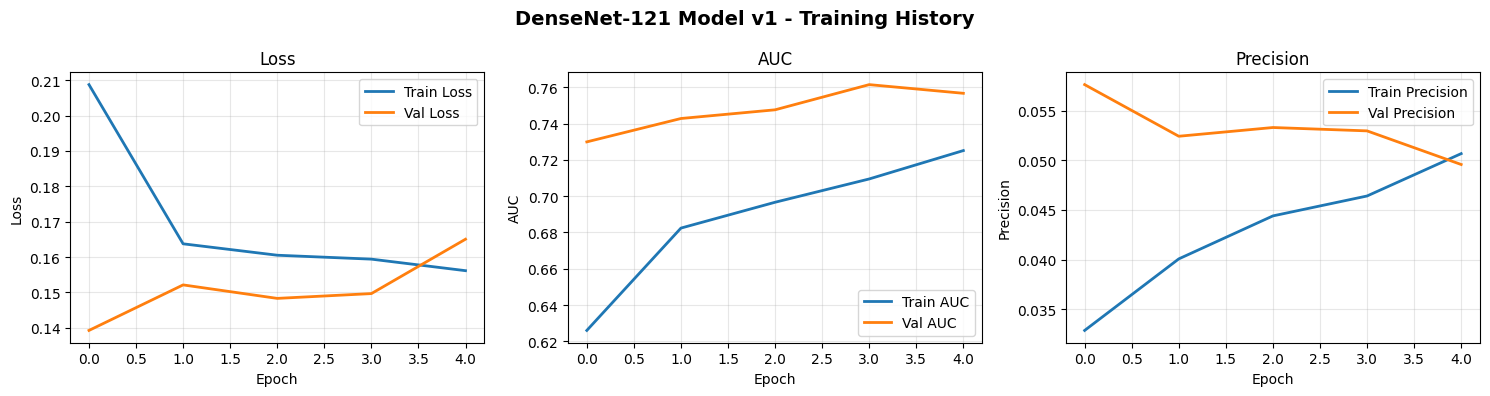


✓ Training history visualization complete.


In [ ]:
print("Available metrics in history:")
print(history_v1.history.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("DenseNet-121 Model v1 - Training History", fontsize=14, fontweight="bold")

axes[0].plot(history_v1.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_v1.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'auc' in history_v1.history:
    axes[1].plot(history_v1.history['auc'], label='Train AUC', linewidth=2)
    axes[1].plot(history_v1.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC')
elif 'AUC' in history_v1.history:
    axes[1].plot(history_v1.history['AUC'], label='Train AUC', linewidth=2)
    axes[1].plot(history_v1.history['val_AUC'], label='Val AUC', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if 'precision' in history_v1.history:
    metric_key = 'precision'
    metric_name = 'Precision'
elif 'Precision' in history_v1.history:
    metric_key = 'Precision'
    metric_name = 'Precision'
else:
    available = [k for k in history_v1.history.keys() if not k.startswith('val_')]
    metric_key = available[-1] if available else None
    metric_name = metric_key.title() if metric_key else 'Metric'

if metric_key and metric_key in history_v1.history:
    axes[2].plot(history_v1.history[metric_key], label=f'Train {metric_name}', linewidth=2)
    axes[2].plot(history_v1.history[f'val_{metric_key}'], label=f'Val {metric_name}', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel(metric_name)
    axes[2].set_title(metric_name)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Training history visualization complete.")

In [ ]:
model_v2 = tf.keras.models.load_model(
    'densenet121_v1_trained.h5',
    custom_objects={'BinaryFocalCrossentropy': loss_fn}
)

base_model_v2 = model_v2.layers[1]

print("DENSENET-121 MODEL (FINE-TUNING - v2)")

base_model_v2.trainable = True

for layer in base_model_v2.layers[:-30]:
    layer.trainable = False

total_params = 0
trainable_params = 0

for layer in base_model_v2.layers:
    layer_params = layer.count_params()
    total_params += layer_params
    if layer.trainable:
        trainable_params += layer_params

print(f"\nBase model layers to be fine-tuned:")
print(f"  Last 30 layers: TRAINABLE")
print(f"  Remaining {len(base_model_v2.layers)-30} layers: FROZEN")
print(f"\nBase model parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Frozen: {total_params - trainable_params:,}")

DENSENET-121 MODEL (FINE-TUNING - v2)

Base model layers to be fine-tuned:
  Last 30 layers: TRAINABLE
  Remaining 397 layers: FROZEN

Base model parameters:
  Total: 7,037,504
  Trainable: 652,032
  Frozen: 6,385,472


In [ ]:
model_v2.compile(
    loss=loss_fn,
    optimizer=Adam(learning_rate=0.0001),
    metrics=['AUC', 'Precision', 'Recall']
)

print("Model v2 recompiled with:")
print("- Loss: Binary Focal Crossentropy (gamma=2.0)")
print("- Optimizer: Adam (lr=0.0001) - LOWER for fine-tuning")
print("- Metrics: AUC, Precision, Recall")


Model v2 recompiled with:
- Loss: Binary Focal Crossentropy (gamma=2.0)
- Optimizer: Adam (lr=0.0001) - LOWER for fine-tuning
- Metrics: AUC, Precision, Recall


In [ ]:
callbacks_v2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_v2.h5',
        monitor='val_auc',
        save_best_only=True,
        verbose=1
    )
]

print("FINE-TUNING DENSENET-121 MODEL (v2)")

EPOCHS_V2 = 5

history_v2 = model_v2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_V2,
    class_weight=class_weights,
    callbacks=callbacks_v2,
    verbose=1
)

print("\n✓ Model v2 fine-tuning completed.")

model_v2.save('densenet121_v2_finetuned.h5')
print("✓ Model v2 saved as 'densenet121_v2_finetuned.h5'")

FINE-TUNING DENSENET-121 MODEL (v2)
Epoch 1/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - AUC: 0.7245 - Precision: 0.0474 - Recall: 0.6227 - loss: 0.1593

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 663s 469ms/step - AUC: 0.7245 - Precision: 0.0474 - Recall: 0.6228 - loss: 0.1593 - val_AUC: 0.7521 - val_Precision: 0.0498 - val_Recall: 0.7214 - val_loss: 0.1467 - learning_rate: 1.0000e-04
Epoch 2/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - AUC: 0.7621 - Precision: 0.0509 - Recall: 0.7203 - loss: 0.1502

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 604s 449ms/step - AUC: 0.7621 - Precision: 0.0509 - Recall: 0.7203 - loss: 0.1502 - val_AUC: 0.7642 - val_Precision: 0.0622 - val_Recall: 0.5274 - val_loss: 0.0988 - learning_rate: 1.0000e-04
Epoch 3/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - AUC: 0.8073 - Precision: 0.0604 - Recall: 0.7605 - loss: 0.1378

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 600s 446ms/step - AUC: 0.8073 - Precision: 0.0604 - Recall: 0.7604 - loss: 0.1379 - val_AUC: 0.7619 - val_Precision: 0.0619 - val_Recall: 0.5920 - val_loss: 0.1033 - learning_rate: 1.0000e-04
Epoch 4/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - AUC: 0.7934 - Precision: 0.0575 - Recall: 0.7364 - loss: 0.1426

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 594s 441ms/step - AUC: 0.7934 - Precision: 0.0575 - Recall: 0.7364 - loss: 0.1426 - val_AUC: 0.7566 - val_Precision: 0.0583 - val_Recall: 0.5871 - val_loss: 0.1013 - learning_rate: 1.0000e-04
Epoch 5/5
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - AUC: 0.8284 - Precision: 0.0640 - Recall: 0.7857 - loss: 0.1348

1345/1345 ━━━━━━━━━━━━━━━━━━━━ 589s 438ms/step - AUC: 0.8284 - Precision: 0.0640 - Recall: 0.7856 - loss: 0.1348 - val_AUC: 0.7579 - val_Precision: 0.0719 - val_Recall: 0.4478 - val_loss: 0.0857 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 5.



✓ Model v2 fine-tuning completed.
✓ Model v2 saved as 'densenet121_v2_finetuned.h5'


Available metrics in history (v2):
dict_keys(['AUC', 'Precision', 'Recall', 'loss', 'val_AUC', 'val_Precision', 'val_Recall', 'val_loss', 'learning_rate'])


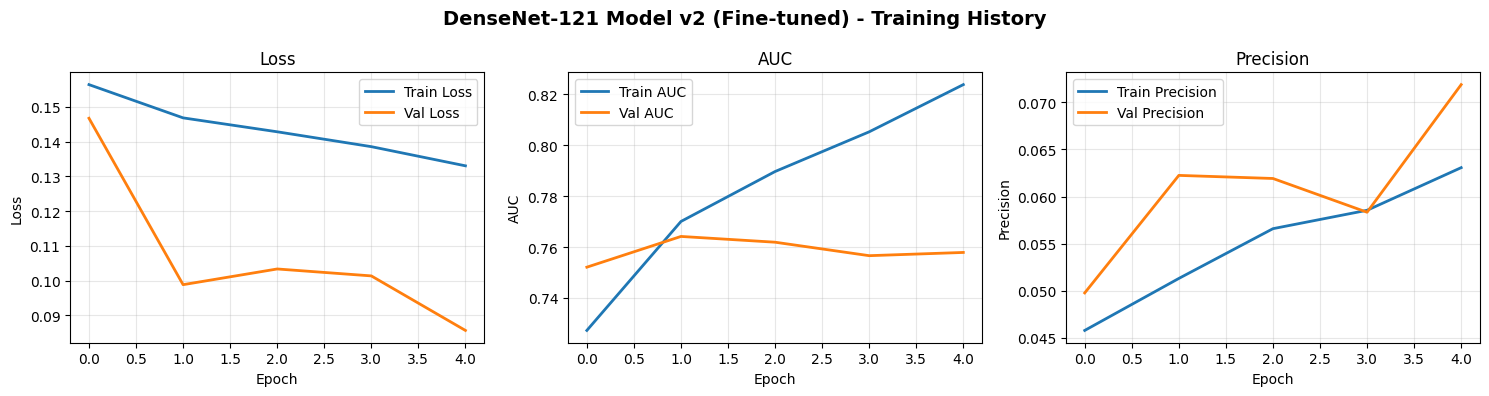


✓ Fine-tuning history visualization complete.


In [ ]:
print("Available metrics in history (v2):")
print(history_v2.history.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("DenseNet-121 Model v2 (Fine-tuned) - Training History", fontsize=14, fontweight="bold")

axes[0].plot(history_v2.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_v2.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'auc' in history_v2.history:
    axes[1].plot(history_v2.history['auc'], label='Train AUC', linewidth=2)
    axes[1].plot(history_v2.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC')
elif 'AUC' in history_v2.history:
    axes[1].plot(history_v2.history['AUC'], label='Train AUC', linewidth=2)
    axes[1].plot(history_v2.history['val_AUC'], label='Val AUC', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

if 'precision' in history_v2.history:
    metric_key = 'precision'
    metric_name = 'Precision'
elif 'Precision' in history_v2.history:
    metric_key = 'Precision'
    metric_name = 'Precision'
else:
    available = [k for k in history_v2.history.keys() if not k.startswith('val_')]
    metric_key = available[-1] if available else None
    metric_name = metric_key.title() if metric_key else 'Metric'

if metric_key and metric_key in history_v2.history:
    axes[2].plot(history_v2.history[metric_key], label=f'Train {metric_name}', linewidth=2)
    axes[2].plot(history_v2.history[f'val_{metric_key}'], label=f'Val {metric_name}', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel(metric_name)
    axes[2].set_title(metric_name)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Fine-tuning history visualization complete.")

In [ ]:
print("GENERATING TEST SET PREDICTIONS")

y_true = []
y_pred_proba = []

for images, labels in test_gen:
    y_true.extend(labels.numpy())
    predictions = model_v2.predict(images, verbose=0)
    y_pred_proba.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"Test set size: {len(y_true)}")
print(f"Predictions generated successfully.")

GENERATING TEST SET PREDICTIONS
Test set size: 9503
Predictions generated successfully.


In [ ]:
print("CLASSIFICATION METRICS")

f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)

print(f"\nF1-Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {ap:.4f}")

print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


CLASSIFICATION METRICS

F1-Score: 0.1824
Precision: 0.1086
Recall: 0.5686
ROC-AUC: 0.8134
Average Precision: 0.1239

--------------------------------------------------
DETAILED CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      0.87      0.93      9248
   Pneumonia       0.11      0.57      0.18       255

    accuracy                           0.86      9503
   macro avg       0.55      0.72      0.55      9503
weighted avg       0.96      0.86      0.91      9503


Confusion Matrix:
[[8058 1190]
 [ 110  145]]


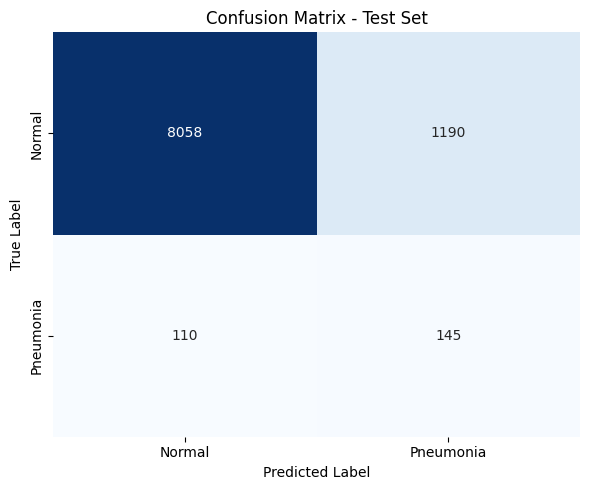

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

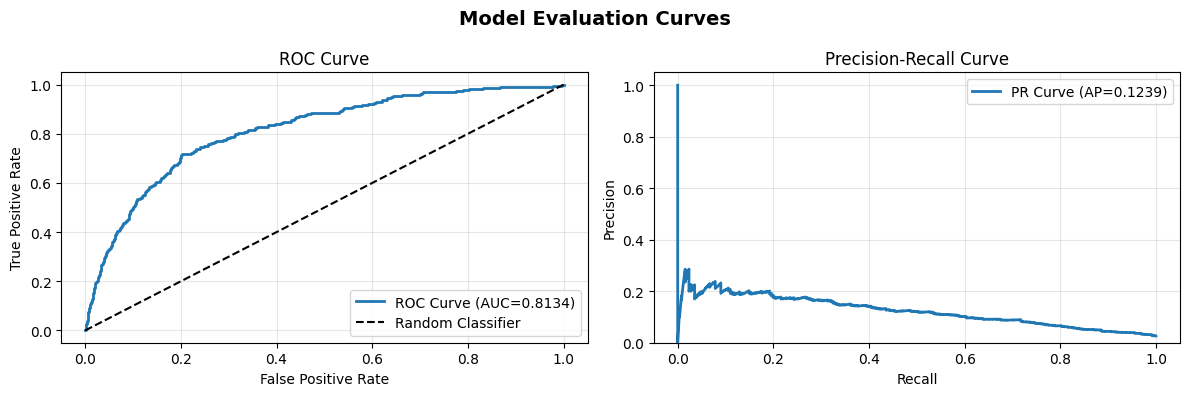

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model Evaluation Curves", fontsize=14, fontweight="bold")

fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0].plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_proba)
axes[1].plot(recall_curve, precision_curve, label=f'PR Curve (AP={ap:.4f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [ ]:
import subprocess
import sys

try:
    import lime
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "-q"])

from lime import lime_image
from skimage.segmentation import mark_boundaries

LIME already installed.


In [ ]:
test_images = []
test_labels = []
test_paths = []

for i, (path, label) in enumerate(zip(test_df["path"].values[:5], test_df["label"].values[:5])):
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        test_images.append(img / 255.0)
        test_labels.append(label)
        test_paths.append(path)
    except Exception as e:
        continue

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(f"Loaded {len(test_images)} test images for LIME interpretation")

def predict_fn(images):
    preprocessed = np.array([preprocess_input(img * 255.0) for img in images])
    predictions = model_v2.predict(preprocessed, verbose=0)
    return np.column_stack([1 - predictions, predictions])

print("✓ LIME prediction function defined.")

Loaded 5 test images for LIME interpretation
✓ LIME prediction function defined.


In [ ]:
print("GENERATING LIME EXPLANATIONS")

explainer = lime_image.LimeImageExplainer()
lime_explanations = []

for idx, img in enumerate(test_images[:3]):
    print(f"Generating LIME explanation for image {idx+1}...")
    
    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=1,
        num_samples=50,
        random_seed=SEED
    )
    
    lime_explanations.append(explanation)
    print(f"✓ Explanation {idx+1} generated.")

print("\n✓ LIME explanations completed.")

GENERATING LIME EXPLANATIONS

Generating LIME explanation for image 1...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Explanation 1 generated.

Generating LIME explanation for image 2...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Explanation 2 generated.

Generating LIME explanation for image 3...


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Explanation 3 generated.

✓ LIME explanations completed.


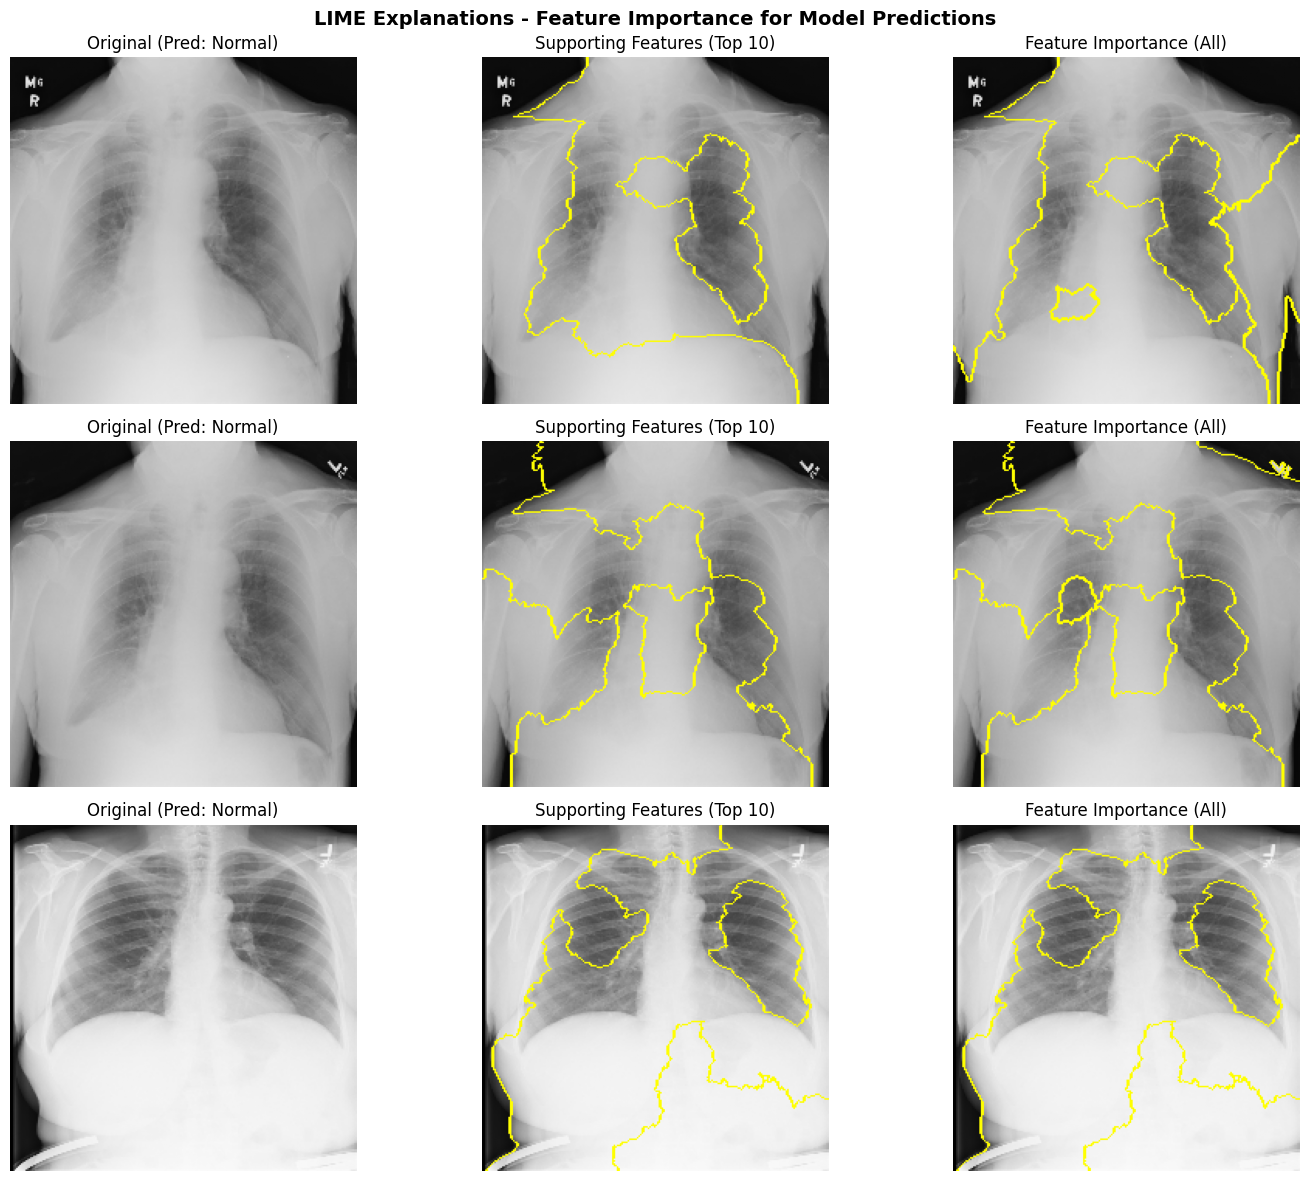

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("LIME Explanations - Feature Importance for Model Predictions", fontsize=14, fontweight="bold")

for idx, (img, explanation) in enumerate(zip(test_images[:3], lime_explanations)):
    label_idx = explanation.top_labels[0]
    label_name = "Pneumonia" if label_idx == 1 else "Normal"
    
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title(f"Original (Pred: {label_name})")
    axes[idx, 0].axis("off")
    
    temp, mask = explanation.get_image_and_mask(
        label_idx,
        positive_only=True,
        num_features=10
    )
    axes[idx, 1].imshow(mark_boundaries(img, mask))
    axes[idx, 1].set_title(f"Supporting Features (Top 10)")
    axes[idx, 1].axis("off")
    
    temp, mask = explanation.get_image_and_mask(
        label_idx,
        positive_only=False,
        num_features=10
    )
    axes[idx, 2].imshow(mark_boundaries(img, mask))
    axes[idx, 2].set_title(f"Feature Importance (All)")
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("SIMPLE GRAD-CAM SETUP")

gradcam_test_images_orig = []
gradcam_test_images_proc = []

for path in test_paths[:3]:
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        
        gradcam_test_images_orig.append(img / 255.0)
        
        img_proc = preprocess_input(img.astype('float32'))
        gradcam_test_images_proc.append(img_proc)
    except Exception as e:
        continue

gradcam_test_images_orig = np.array(gradcam_test_images_orig)
gradcam_test_images_proc = np.array(gradcam_test_images_proc)

print(f"✓ Prepared {len(gradcam_test_images_orig)} images for Grad-CAM")

def get_gradcam_heatmap(model, img_array, last_conv_layer_name='conv5_block16_concat'):
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    
    base_model = model.get_layer("densenet121")
    conv_layer = base_model.get_layer(last_conv_layer_name)
    
    conv_model = tf.keras.Model(inputs=base_model.input, outputs=conv_layer.output)
    pred_model = model
    
    with tf.GradientTape() as tape:
        conv_features = conv_model(img_array, training=False)
        tape.watch(conv_features)
        
        predictions = pred_model(img_array, training=False)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_features)
    
    if grads is None:
        heatmap = tf.reduce_mean(tf.abs(conv_features[0]), axis=2)
    else:
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_features_out = conv_features[0]
        heatmap = conv_features_out @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0)
    
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

print("✓ Simple Grad-CAM function ready!")

SIMPLE GRAD-CAM SETUP
✓ Prepared 3 images for Grad-CAM
✓ Simple Grad-CAM function ready!


In [ ]:
print("GENERATING GRAD-CAM HEATMAPS")

gradcam_heatmaps = []

for idx, img_proc in enumerate(gradcam_test_images_proc):
    print(f"Generating Grad-CAM for image {idx+1}...")
    
    img_batch = np.expand_dims(img_proc, axis=0)
    
    heatmap = get_gradcam_heatmap(model_v2, img_batch, last_conv_layer_name='conv5_block16_concat')
    gradcam_heatmaps.append(heatmap)
    
    print(f"✓ Grad-CAM {idx+1} generated (size: {heatmap.shape})")

print(f"\n✓ All {len(gradcam_heatmaps)} Grad-CAM heatmaps ready!")

GENERATING GRAD-CAM HEATMAPS
Generating Grad-CAM for image 1...
Note: Using fallback activation method (gradients unavailable)
✓ Grad-CAM 1 generated (size: (7, 7))
Generating Grad-CAM for image 2...
Note: Using fallback activation method (gradients unavailable)
✓ Grad-CAM 2 generated (size: (7, 7))
Generating Grad-CAM for image 3...
Note: Using fallback activation method (gradients unavailable)
✓ Grad-CAM 3 generated (size: (7, 7))

✓ All 3 Grad-CAM heatmaps ready!


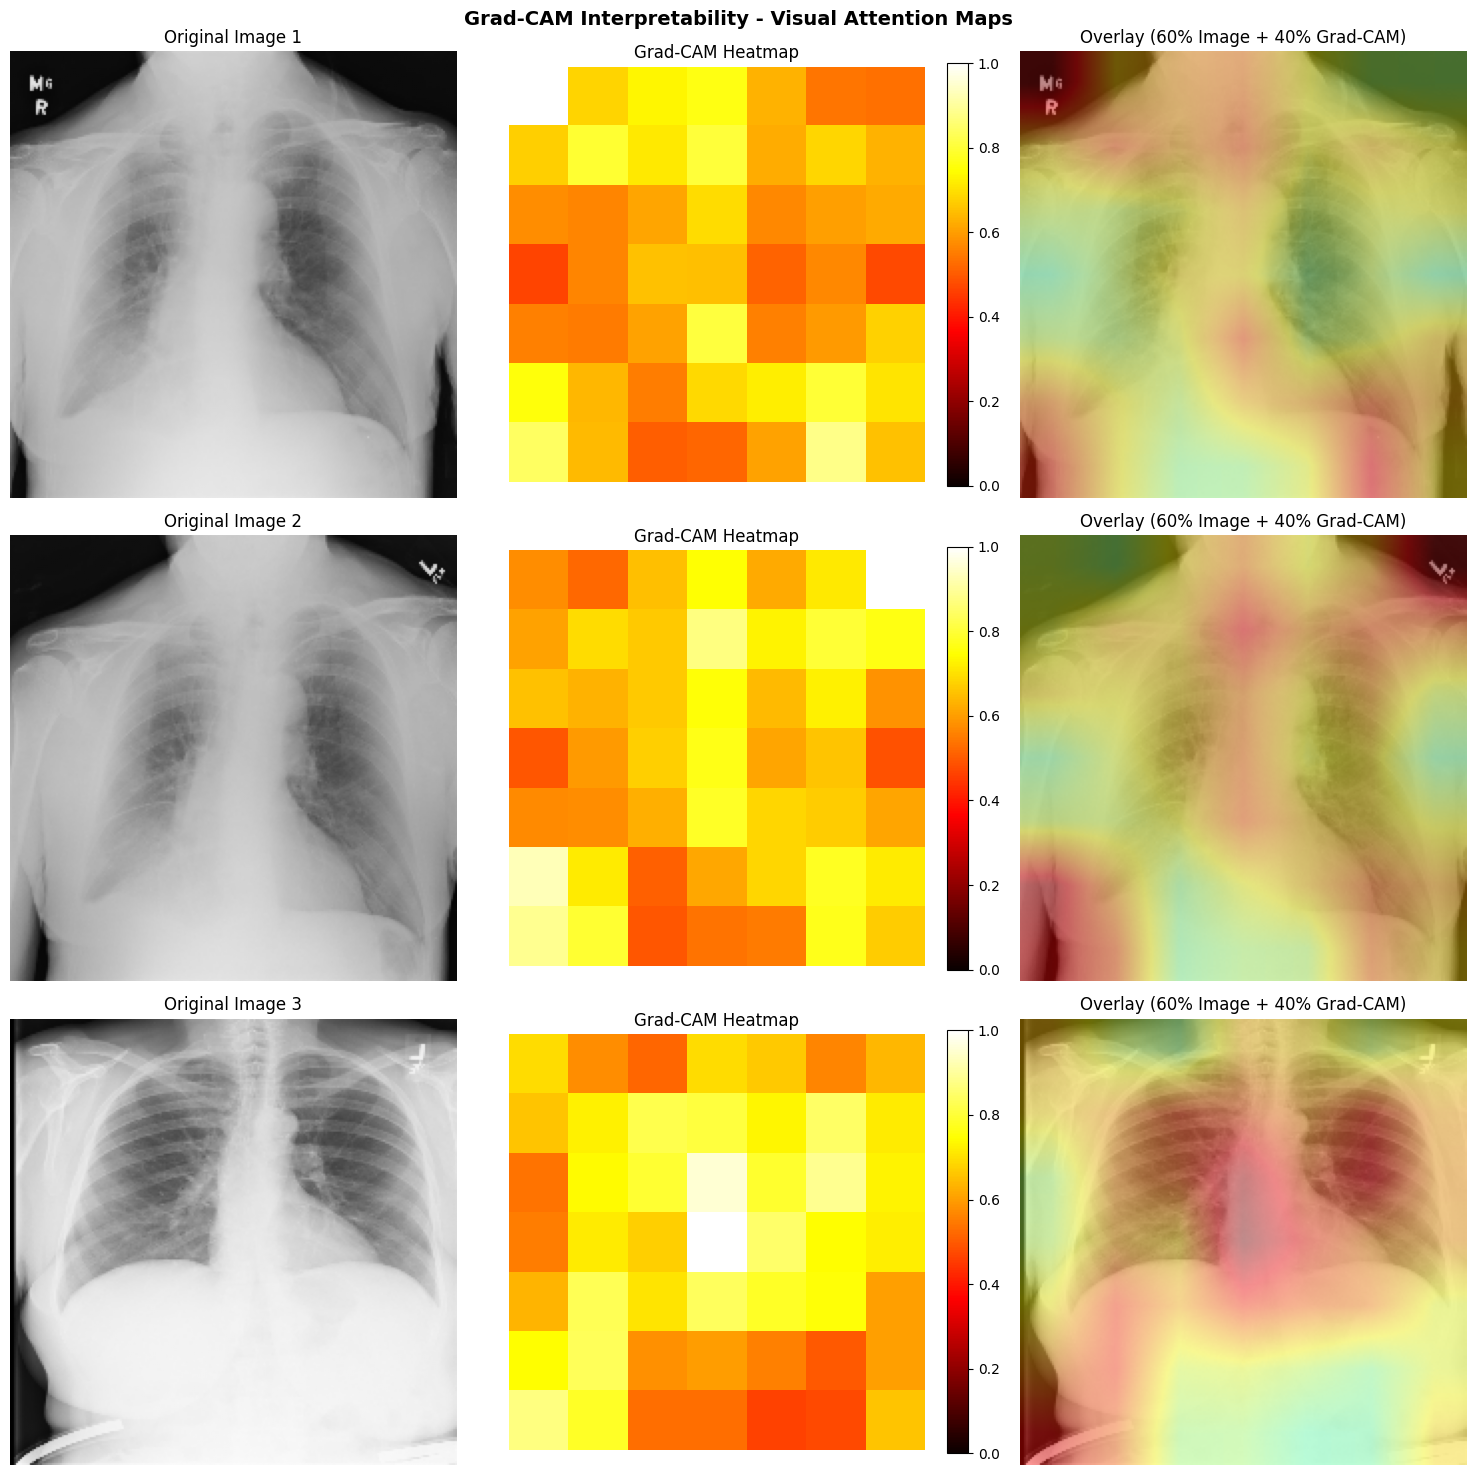

✓ Grad-CAM visualization complete!


In [ ]:
fig, axes = plt.subplots(len(gradcam_heatmaps), 3, figsize=(15, 5*len(gradcam_heatmaps)))

if len(gradcam_heatmaps) == 1:
    axes = axes.reshape(1, -1)

fig.suptitle("Grad-CAM Interpretability - Visual Attention Maps", fontsize=14, fontweight="bold")

for idx, (img_orig, heatmap) in enumerate(zip(gradcam_test_images_orig, gradcam_heatmaps)):
    axes[idx, 0].imshow(img_orig, cmap='gray')
    axes[idx, 0].set_title(f"Original Image {idx+1}")
    axes[idx, 0].axis("off")
    
    im2 = axes[idx, 1].imshow(heatmap, cmap='hot', vmin=0, vmax=1)
    axes[idx, 1].set_title(f"Grad-CAM Heatmap")
    axes[idx, 1].axis("off")
    plt.colorbar(im2, ax=axes[idx, 1], fraction=0.046)
    
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(
        (heatmap_resized * 255).astype('uint8'), 
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    overlay = 0.6 * img_orig + 0.4 * heatmap_colored
    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(f"Overlay (60% Image + 40% Grad-CAM)")
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.show()

print("✓ Grad-CAM visualization complete!")